# NetGuardAI — EDA (CICIDS2017)


In [1]:
import glob
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

RAW_DIR = Path('../data/raw/MachineLearningCVE')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 1  Load data

In [2]:
frames = [pd.read_csv(f, low_memory=False) for f in sorted(RAW_DIR.glob('*.csv'))]
df = pd.concat(frames, ignore_index=True)
df.columns = df.columns.str.strip()
print(f'Raw shape: {df.shape}')

Raw shape: (2830743, 79)


## 2  Basic stats

In [3]:
feature_cols = [c for c in df.columns if c != 'Label']

total_rows   = len(df)
missing      = df[feature_cols].isna().sum().sum()
inf_count    = np.isinf(df[feature_cols].select_dtypes(include=[np.number])).sum().sum()
label_counts = df['Label'].value_counts()
benign_n     = label_counts.get('BENIGN', 0)
attack_n     = label_counts.drop('BENIGN').sum()
imbalance    = benign_n / attack_n

print(f'Total rows            : {total_rows:,}')
print(f'Missing values        : {missing:,}')
print(f'Inf values            : {inf_count:,}')
print(f'Number of classes     : {df["Label"].nunique()}')
print(f'Imbalance ratio (B/A) : {imbalance:.2f}x')
print()
print(label_counts.to_string())

Total rows            : 2,830,743
Missing values        : 1,358
Inf values            : 4,376
Number of classes     : 15
Imbalance ratio (B/A) : 4.08x

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11


## 3  Class distribution (log scale)

/var/folders/10/471w2rks2_g1vsz0bq3bm2_00000gn/T/ipykernel_23551/3393468600.py:14: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/10/471w2rks2_g1vsz0bq3bm2_00000gn/T/ipykernel_23551/3393468600.py:15: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.savefig('../data/processed/images/class_distribution.png', bbox_inches='tight')
/Users/apple/Desktop/NetGuardAI/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


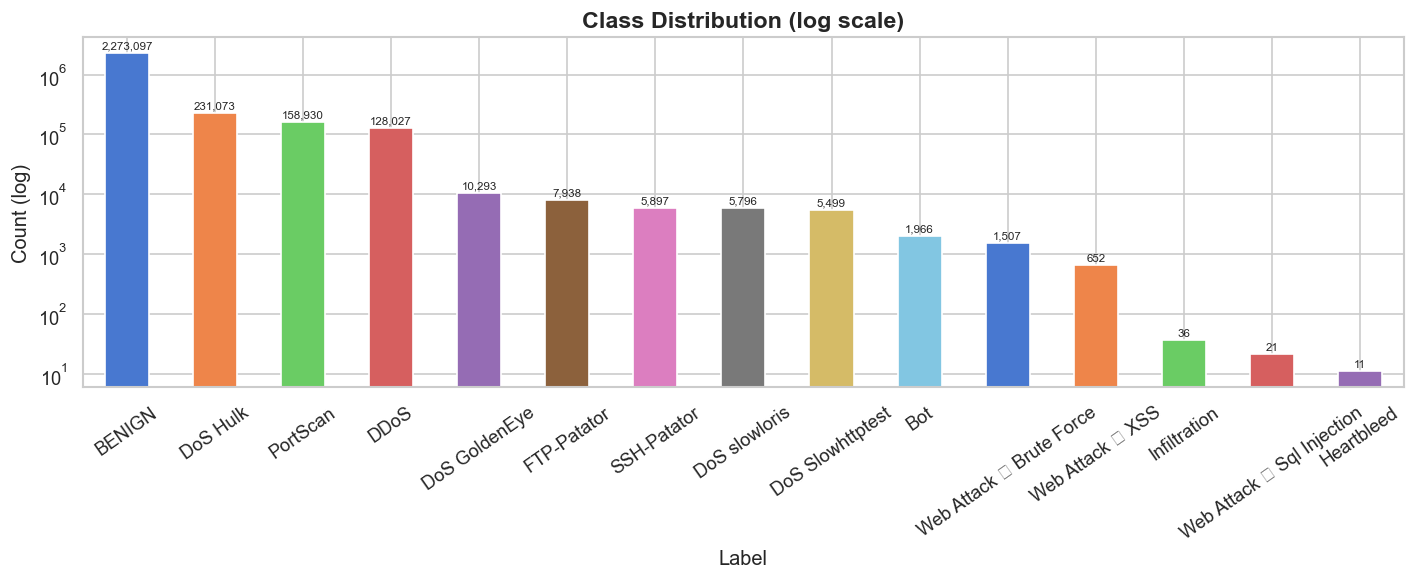

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
label_counts.sort_values(ascending=False).plot(
    kind='bar', ax=ax, color=sns.color_palette('muted', len(label_counts))
)
ax.set_yscale('log')
ax.set_title('Class Distribution (log scale)', fontsize=14, fontweight='bold')
ax.set_xlabel('Label')
ax.set_ylabel('Count (log)')
ax.tick_params(axis='x', rotation=35)
for bar in ax.patches:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h * 1.1, f'{int(h):,}',
            ha='center', va='bottom', fontsize=7, rotation=0)
plt.tight_layout()
plt.savefig('../data/processed/images/class_distribution.png', bbox_inches='tight')
plt.show()

## 4  Clean for correlation & feature-importance

In [8]:
df_clean = df.copy()
df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
df_clean = df_clean.dropna().drop_duplicates().reset_index(drop=True)
num_cols = [c for c in feature_cols if df_clean[c].dtype != object]
print(f'Shape after cleaning: {df_clean.shape}')

Shape after cleaning: (2520798, 79)


## 5  Top-20 feature correlation heatmap

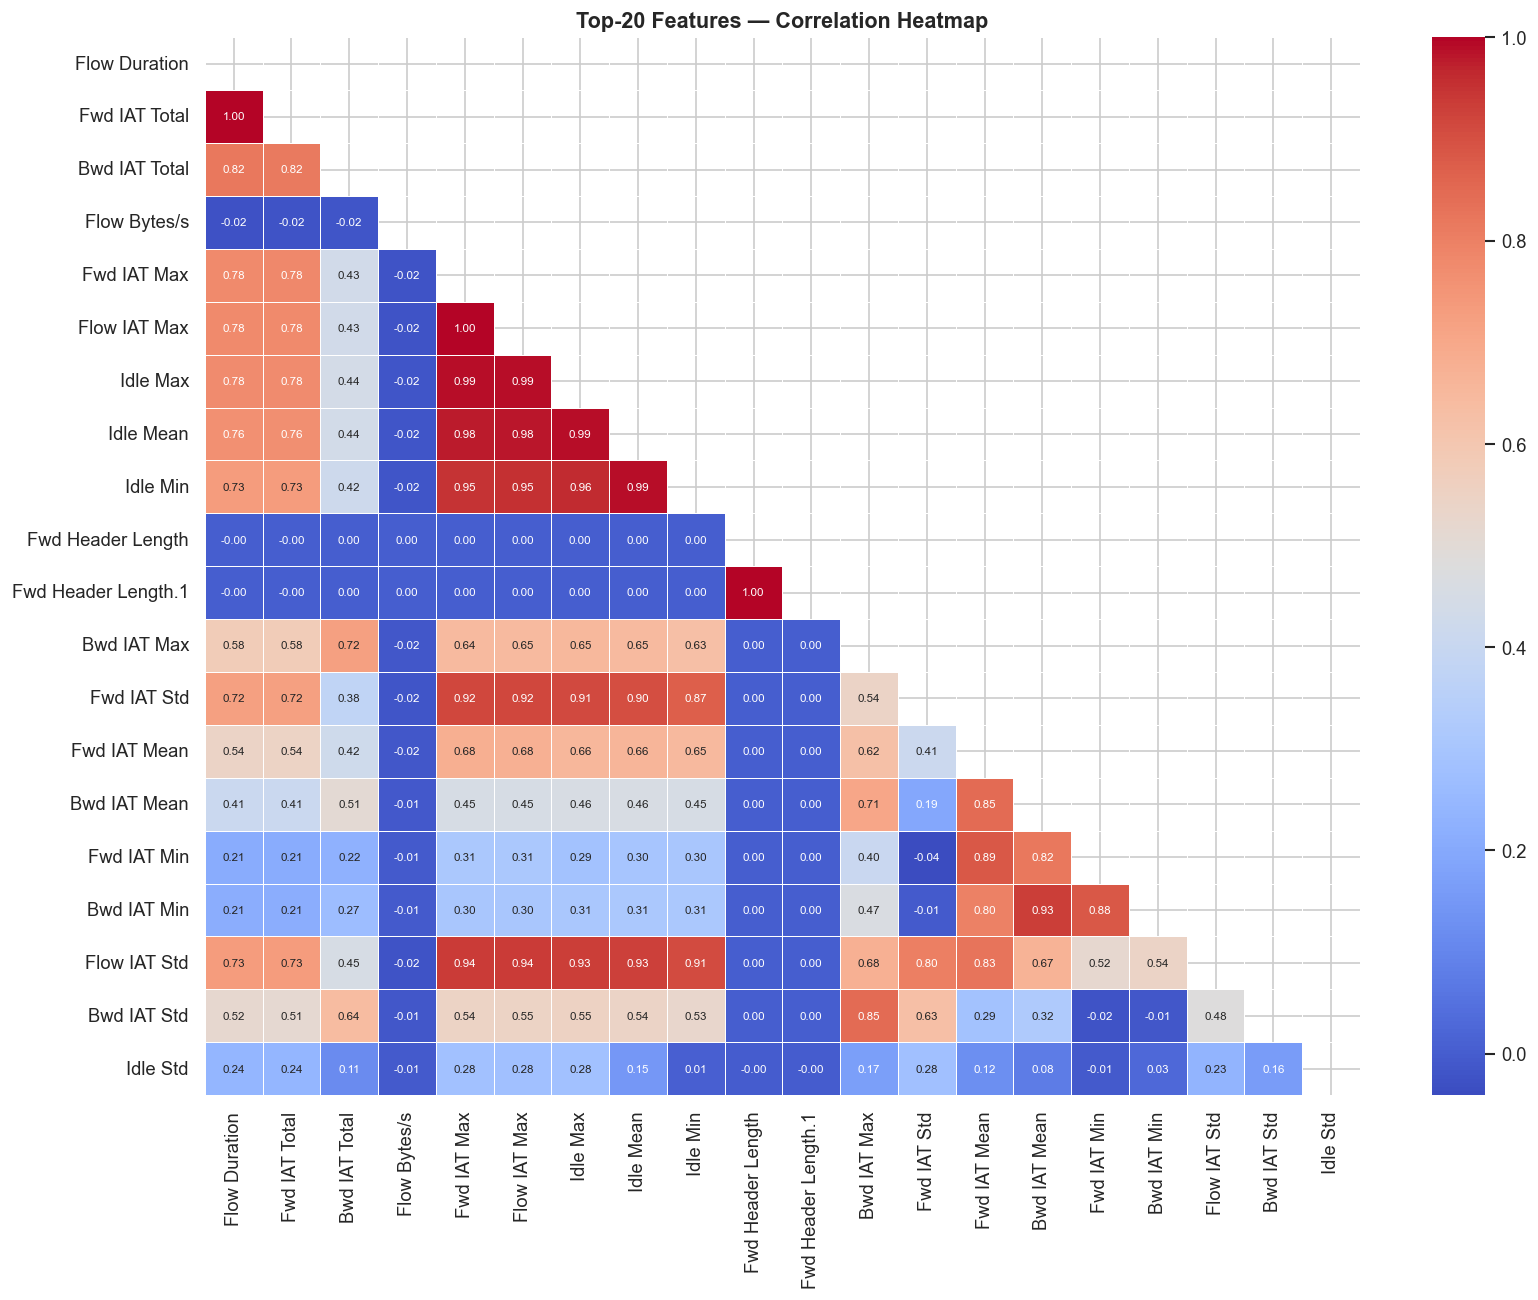

In [9]:
# Use top-20 features by variance for a readable heatmap
top20_var = df_clean[num_cols].var().nlargest(20).index.tolist()
corr = df_clean[top20_var].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.4, linecolor='white', ax=ax, annot_kws={'size': 7}
)
ax.set_title('Top-20 Features — Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/images/correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 6  Feature importance preview (quick RandomForest)

/var/folders/10/471w2rks2_g1vsz0bq3bm2_00000gn/T/ipykernel_23551/3883269254.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = df_clean.groupby('Label', group_keys=False).apply(


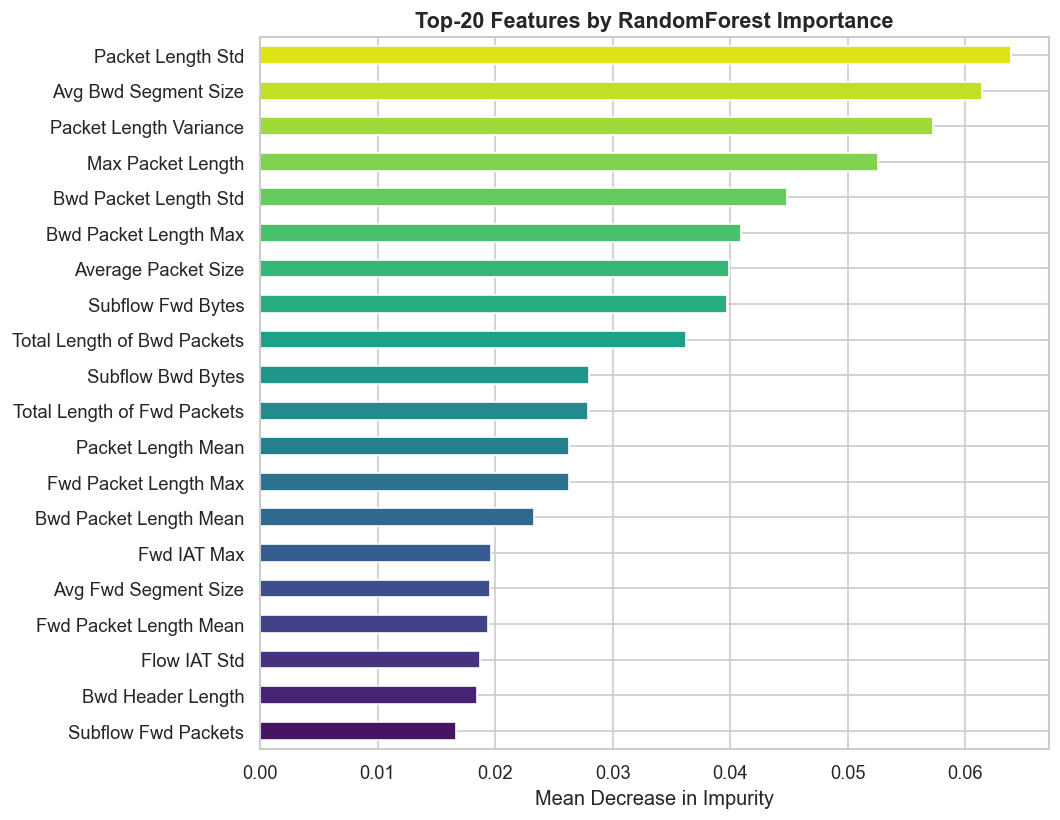

Packet Length Std              0.063915
Avg Bwd Segment Size           0.061425
Packet Length Variance         0.057247
Max Packet Length              0.052599
Bwd Packet Length Std          0.044868
Bwd Packet Length Max          0.040910
Average Packet Size            0.039867
Subflow Fwd Bytes              0.039701
Total Length of Bwd Packets    0.036260
Subflow Bwd Bytes              0.027953
Total Length of Fwd Packets    0.027887
Packet Length Mean             0.026310
Fwd Packet Length Max          0.026269
Bwd Packet Length Mean         0.023322
Fwd IAT Max                    0.019686
Avg Fwd Segment Size           0.019553
Fwd Packet Length Mean         0.019361
Flow IAT Std                   0.018683
Bwd Header Length              0.018446
Subflow Fwd Packets            0.016664


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Subsample for speed (5 % stratified)
sample = df_clean.groupby('Label', group_keys=False).apply(
    lambda g: g.sample(frac=0.05, random_state=42)
).reset_index(drop=True)

X_s = sample[num_cols].values
y_s = LabelEncoder().fit_transform(sample['Label'].values)

rf = RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1, random_state=42)
rf.fit(X_s, y_s)

importances = pd.Series(rf.feature_importances_, index=num_cols)
top20_imp = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
top20_imp.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', 20))
ax.set_title('Top-20 Features by RandomForest Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig('../data/processed/images/feature_importance.png', bbox_inches='tight')
plt.show()
print(top20_imp.sort_values(ascending=False).to_string())